In [25]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder,FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA


Vamos a relizar 5 modelos supervisados tenemos clasificación y usamos un modelo no supervisado 

Regresión Logística (Logistic Regression)

Bosques Aleatorios (Random Forest)

Máquina de Vectores de Soporte (SVC)

Gradient Boosting

K-Nearest Neighbors (KNN)

KMeans -> Descartado

PCA -> Aprobado



In [26]:
df = pd.read_csv('../data/processed/dataset_final.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

In [27]:
df

,gender,SeniorCitizen,Partner,Dependents,Antiguedad,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [28]:
#conversión de las columnas binarias . Por ejemplo las que son TRUE / False se conviertente a 1 / 0
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# Seleccionamos las features de cada tipo, categoricas y númericas para luego poder preprocesarlas.
num_features = ['Antiguedad', 'SeniorCitizen', 'MonthlyCharges','TotalCharges' ]
cat_features = ['InternetService', 'PaymentMethod', 'Contract', 
    'PaperlessBilling', 'OnlineSecurity', 'TechSupport']
log_features = ['TotalCharges']



In [30]:
# Creamos 1 pipeline por cada 1 de las features
pre_num = Pipeline(steps=[
    ('scaler', StandardScaler())
])
pre_cat = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
pre_log = Pipeline(steps=[
    ('logaritmico', FunctionTransformer(np.log1p, validate=True))
])

In [31]:
# Creamos el ColumnTransformer
ct = ColumnTransformer(transformers=[
    ('log', pre_log, log_features),
    ('num', pre_num, num_features),
    ('cat', pre_cat, cat_features)
])

In [32]:
# dividimos en train y test, recordamos siempre la regla del 80% / 20% para train y test y de paso guardamso la variable semilla a 42
semilla = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla, stratify=y)

In [33]:
# diccionario con los modelos 
modelos = {
    'Regresion_Logistica': LogisticRegression(max_iter=1000, random_state=semilla,class_weight='balanced'),
    'Random_Forest': RandomForestClassifier(random_state=semilla,class_weight='balanced'),
    'SVM(SVC)': SVC(probability=True, random_state=semilla,class_weight='balanced'),
    'Gradient_Boosting': GradientBoostingClassifier(random_state=semilla),
    'K-NN': KNeighborsClassifier()
}

In [34]:
#for del pipeline para guardar los resultados y seleccionar modelo
clusters=5 # numero de clusters, no pasarse
pipelines = {}
for name, model in modelos.items():

    pipelines[name] = Pipeline(steps=[
        ('preprocessor', ct),
        ('smote', SMOTE(random_state=42)),
        ('PCA', PCA(n_components=0.95)), # AÑADIMOS PCA PARA VER SI ASI ELIMINAMOS LAS VARIABLES DUPLICADAS
        ('clasificador', model)
    ])

resultados = []
best_acc = 0
best_model_name = ""
best_cm = None  # Variable para guardar la mejor matriz

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Guardar en el diccionario de resultados
    resultados.append({
        'Modelo': name, 
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })  
    
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_cm = confusion_matrix(y_test, y_pred)

In [35]:
results_df = pd.DataFrame(resultados).sort_values(by='Recall', ascending=False)
print("Resumen Completo de Métricas:")
print(results_df.to_string(index=False))
print("Matriz de Confusión del mejor modelo:")
print(best_cm)
print (best_model_name)

Resumen Completo de Métricas:
             Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
           SVM(SVC)    0.7410     0.5077  0.7888    0.6178   0.8225
Regresion_Logistica    0.7537     0.5243  0.7781    0.6265   0.8437
  Gradient_Boosting    0.7480     0.5172  0.7647    0.6170   0.8313
               K-NN    0.6955     0.4536  0.7193    0.5564   0.7704
      Random_Forest    0.7658     0.5531  0.6123    0.5812   0.8089
Matriz de Confusión del mejor modelo:
[[850 185]
 [145 229]]
Random_Forest


In [36]:
results_df.to_csv('../data/processed/resultados_modelos.csv', index=False)

In [37]:
results_df

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,SVM(SVC),0.7410,0.5077,0.7888,0.6178,0.8225
0,Regresion_Logistica,0.7537,0.5243,0.7781,0.6265,0.8437
3,Gradient_Boosting,0.7480,0.5172,0.7647,0.6170,0.8313
4,K-NN,0.6955,0.4536,0.7193,0.5564,0.7704
1,Random_Forest,0.7658,0.5531,0.6123,0.5812,0.8089


In [38]:
# Guardar modelos por separado

for nombre, pipeline in pipelines.items():
    # Limpiamos el nombre para que no tenga espacios ni paréntesis en el archivo
    nombre_limpio = nombre.replace(" ", "_").replace("(", "").replace(")", "")
    nombre_archivo = f"../models/trained_model_{nombre_limpio}.pkl"
    
    # Guardamos el pipeline individual directamente en la ruta actual
    joblib.dump(pipeline, nombre_archivo)
    print(f" -> Guardado: {nombre_archivo}")

print("\n¡Todos los modelos han sido guardados individualmente!")

 -> Guardado: ../models/trained_model_Regresion_Logistica.pkl
 -> Guardado: ../models/trained_model_Random_Forest.pkl
 -> Guardado: ../models/trained_model_SVMSVC.pkl
 -> Guardado: ../models/trained_model_Gradient_Boosting.pkl
 -> Guardado: ../models/trained_model_K-NN.pkl

¡Todos los modelos han sido guardados individualmente!


In [39]:
modelo_seleccionado = modelos['Regresion_Logistica']

modelo_final = Pipeline([
    ('preprocessor', ct),
    ('smote', SMOTE(random_state=42)),
    ('PCA', PCA(n_components=0.95)), # AÑADIMOS PCA PARA VER SI ASI ELIMINAMOS LAS VARIABLES DUPLICADAS # pasamos los mismos trasnfromadores que en el for de todos los modelos.
    ('clasificador', modelo_seleccionado) # modelo seleccionado con mejor metrica / velocidad
])

# definimos los parametros del gridsearch
param_grid = [
    {
        'clasificador__solver': ['liblinear'], 
        'clasificador__penalty': ['l1', 'l2'], 
        'clasificador__C': [0.001, 0.01, 0.1, 1, 10],
    },
    {
        'clasificador__solver': ['lbfgs'], 
        'clasificador__penalty': ['l2'], 
        'clasificador__C': [0.001, 0.01, 0.1, 1, 10],
        'clasificador__max_iter': [1000],
    }
]

grid_search = GridSearchCV(
    estimator=modelo_final, # pipeline solo del modelo ganador
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

In [40]:
grid_search.fit(X_train, y_train)

/home/danilavia/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/danilavia/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/danilavia/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clasificador__C': [0.001, 0.01, ...], 'clasificador__penalty': ['l1', 'l2'], 'clasificador__solver': ['liblinear']}, {'clasificador__C': [0.001, 0.01, ...], 'clasificador__max_iter': [1000], 'clasificador__penalty': ['l2'], 'clasificador__solver': ['lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to

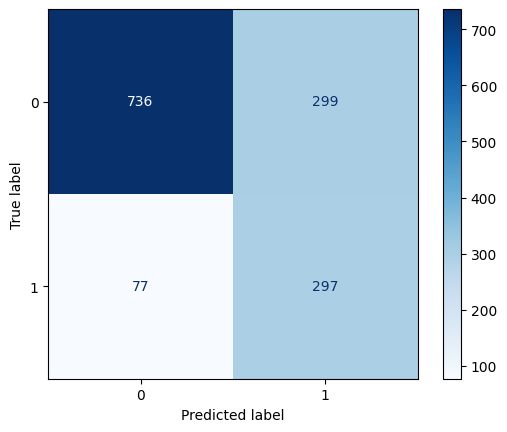

In [41]:
y_pred = grid_search.predict(X_test)

# 4. Generar la matriz
cm = confusion_matrix(y_test, y_pred)

# 5. Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)
disp.plot(cmap='Blues')

In [42]:
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

# Mostrar el mejor "score" (exactitud media en validación cruzada)
print(f"\nMejor exactitud (CV Score): {grid_search.best_score_:.4f}")

Mejores hiperparámetros:
{'clasificador__C': 0.001, 'clasificador__penalty': 'l1', 'clasificador__solver': 'liblinear'}

Mejor exactitud (CV Score): 0.7766


In [43]:
resultados_df = pd.DataFrame(grid_search.cv_results_)

# Seleccionar solo las columnas que más importan y ordenarlas por el mejor resultado
resumen = resultados_df[['rank_test_score', 'mean_test_score', 'params']]
resumen_ordenado = resumen.sort_values(by='rank_test_score')

In [44]:
resumen_ordenado

,rank_test_score,mean_test_score,params
0,1,0.776589,"{'clasificador__C': 0.001, 'clasificador__pena..."
4,2,0.771237,"{'clasificador__C': 0.1, 'clasificador__penalt..."
5,3,0.769900,"{'clasificador__C': 0.1, 'clasificador__penalt..."
12,3,0.769900,"{'clasificador__C': 0.1, 'clasificador__max_it..."
7,5,0.769231,"{'clasificador__C': 1, 'clasificador__penalty'..."
6,5,0.769231,"{'clasificador__C': 1, 'clasificador__penalty'..."
8,7,0.768562,"{'clasificador__C': 10, 'clasificador__penalty..."
13,8,0.767893,"{'clasificador__C': 1, 'clasificador__max_iter..."
14,8,0.767893,"{'clasificador__C': 10, 'clasificador__max_ite..."
9,8,0.767893,"{'clasificador__C': 10, 'clasificador__penalty..."


In [45]:
#seleccionamso el mejor estimador
mejor_pipeline_final = grid_search.best_estimator_

#guardamos el modelo que será el que usemos para predecir.
nombre_archivo = '../models/final_model.pkl'
joblib.dump(mejor_pipeline_final, nombre_archivo)

['../models/final_model.pkl']

In [46]:
modelo_produccion = joblib.load('../models/final_model.pkl')

nuevos_datos = pd.DataFrame({
    # Numéricas
    'Antiguedad':[12,34],
    'SeniorCitizen':[0,1],
    'MonthlyCharges': [23,65],
    'TotalCharges': [3500,2300],
    # Categóricas
    'gender':['Male','Female'],
    'Partner':['No','Yes'] ,
    'Dependents':['No','Yes'] ,
    'PhoneService':['No','Yes']  ,
    'MultipleLines':['No','Yes']  , 
    'InternetService':['No','Yes']  ,
    'OnlineSecurity':['No','Yes']  ,
    'OnlineBackup':['No','Yes']  ,
    'DeviceProtection':['No','Yes']  , 
    'TechSupport': ['No','Yes'] ,
    'StreamingTV': ['No','Yes']  ,
    'StreamingMovies': ['No','Yes']  ,
    'Contract': ['Month-to-month','One Year'],
    'PaperlessBilling':['No','Yes'] ,
    'PaymentMethod':['Mailed check', 'Electronic check'] 
})

predicciones = modelo_produccion.predict(nuevos_datos)
probabilidades = modelo_produccion.predict_proba(nuevos_datos)

# 5. Visualizar el resultado final
nuevos_datos['Prediccion_Modelo'] = predicciones
nuevos_datos['Crush Rate'] = probabilidades[:, 1] # Probabilidad de ser la clase positiva

print("--- RESULTADOS DE LAS PREDICCIONES ---")
print(nuevos_datos[['Antiguedad', 'PaymentMethod', 'Prediccion_Modelo', 'Crush Rate']])

--- RESULTADOS DE LAS PREDICCIONES ---
   Antiguedad     PaymentMethod  Prediccion_Modelo  Crush Rate
0          12      Mailed check                  0    0.317233
1          34  Electronic check                  1    0.609061


/home/danilavia/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [5, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/danilavia/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [5, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [47]:
# Ponemos a prueba el modelo con un csv generado sinteticamente.

modelo_produccion = joblib.load('../models/final_model.pkl')
# 2. Recibir o crear los DATOS NUEVOS
# IMPORTANTE: Deben ser las mismas columnas con las que entrenaste (X_train)
csv = pd.read_csv('../data/processed/datos_prueba_ml2.csv')

predicciones = modelo_produccion.predict(csv)
probabilidades = modelo_produccion.predict_proba(csv)

# 5. Visualizar el resultado final
csv['Prediccion_Modelo'] = predicciones
csv['Crush Rate'] = probabilidades[:, 1] # Probabilidad de ser la clase positiva

print("--- RESULTADOS DE LAS PREDICCIONES ---")
print(csv[['customerID','Antiguedad', 'PaymentMethod', 'Prediccion_Modelo', 'Crush Rate']])



--- RESULTADOS DE LAS PREDICCIONES ---
         customerID  Antiguedad              PaymentMethod  Prediccion_Modelo  \
0     sdv-id-pJvgxt          43           Electronic check                  0   
1     sdv-id-QZoJix          29               Mailed check                  0   
2     sdv-id-sUpodm          71    Credit card (automatic)                  0   
3     sdv-id-VQZvMN           3               Mailed check                  1   
4     sdv-id-fHaBym          19    Credit card (automatic)                  0   
...             ...         ...                        ...                ...   
2995  sdv-id-Fmtawh          70           Electronic check                  1   
2996  sdv-id-rxOgFc          13           Electronic check                  1   
2997  sdv-id-jBlECX          32  Bank transfer (automatic)                  0   
2998  sdv-id-qROYcp          35    Credit card (automatic)                  0   
2999  sdv-id-TcDbKz           4           Electronic check            

In [48]:
csv.to_csv('../data/processed/datos_procesados.csv', index=False)